# Wickramarachchi T  T and IT22243980 — Decision Tree

**Dataset:** Telco  
**Algorithm:** Decision Tree  
**Goal:** Predict whether a passenger survived (1) or not (0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv('Telco_csv.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [4]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


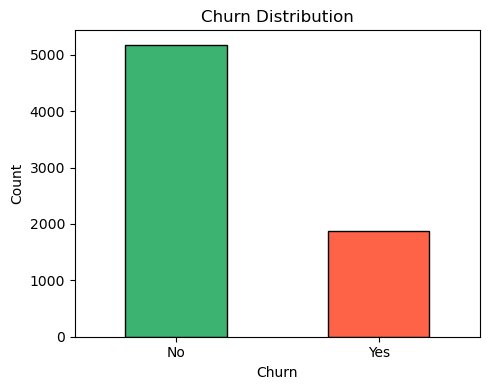

Saved: dt_churn_distribution.png


In [5]:
# Churn distribution
print('Churn value counts:')
print(df['Churn'].value_counts())

plt.figure(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['mediumseagreen', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('dt_churn_distribution.png', dpi=150)
plt.show()
print('Saved: dt_churn_distribution.png')

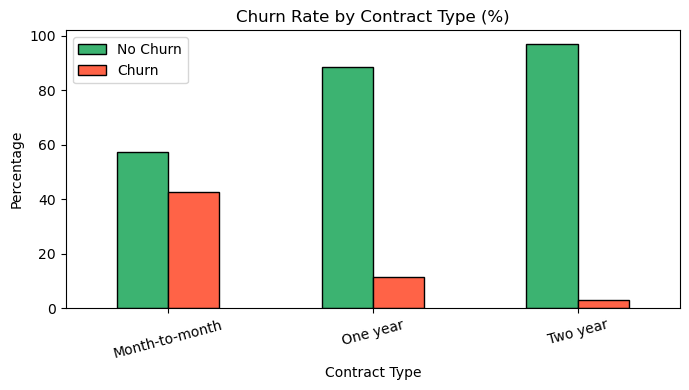

Saved: dt_contract_churn.png


In [6]:
# Contract type vs Churn — gives us a business insight
plt.figure(figsize=(7, 4))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', color=['mediumseagreen', 'tomato'], edgecolor='black', ax=plt.gca())
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=15)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('dt_contract_churn.png', dpi=150)
plt.show()
print('Saved: dt_contract_churn.png')

In [7]:
# Fix TotalCharges and drop NaN rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (7032, 21)


In [8]:
df.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df['gender'] = le.fit_transform(df['gender'])

multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print('Final dataset shape after encoding:', df.shape)

Final dataset shape after encoding: (7032, 31)


In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

# NOTE: Decision Trees do NOT need feature scaling

Training samples : 5625
Testing samples  : 1407


In [10]:
# Train with max_depth=5 to avoid overfitting (tree growing too deep/complex)
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

print('Model training complete!')
print(f'Tree depth: {model_dt.get_depth()}')
print(f'Number of leaves: {model_dt.get_n_leaves()}')

Model training complete!
Tree depth: 5
Number of leaves: 32


In [11]:
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_dt)
roc_auc  = roc_auc_score(y_test, y_prob_dt)

print('=' * 45)
print('         DECISION TREE RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

         DECISION TREE RESULTS
  Accuracy  : 0.7783 (77.83%)
  ROC-AUC   : 0.8195

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [12]:
# Cross-validation
cv_scores = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual fold scores: {[round(s,4) for s in cv_scores]}')

Cross-Validation Accuracy (5-fold): 0.7895 ± 0.0141
Individual fold scores: [np.float64(0.7858), np.float64(0.8044), np.float64(0.8071), np.float64(0.7707), np.float64(0.7796)]


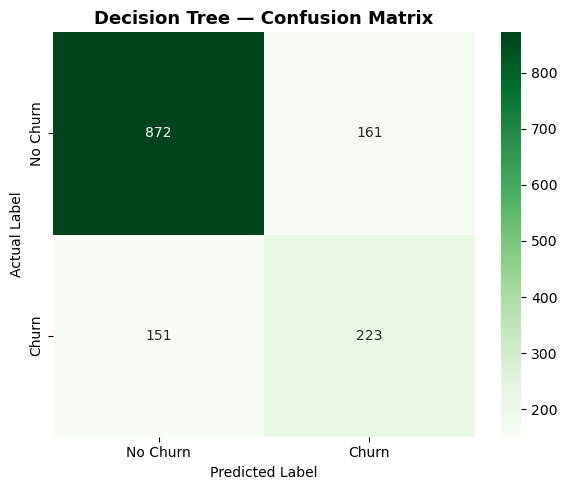

Saved: dt_confusion_matrix.png


In [13]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: dt_confusion_matrix.png')

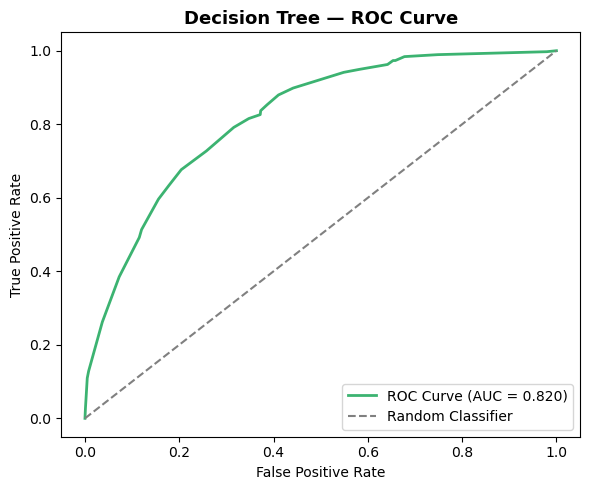

Saved: dt_roc_curve.png


In [14]:
# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='mediumseagreen', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree — ROC Curve', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=150)
plt.show()
print('Saved: dt_roc_curve.png')

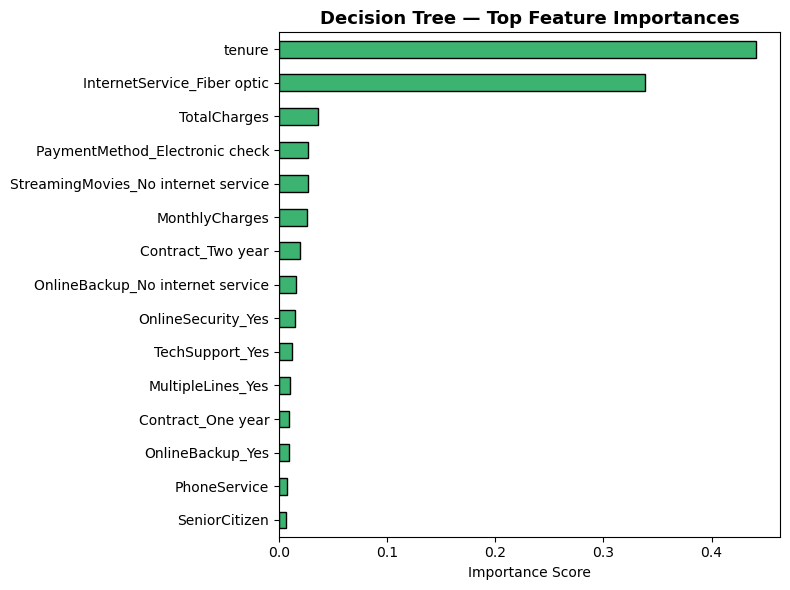

Saved: dt_feature_importance.png


In [15]:
# 3. Feature Importance
feat_imp = pd.Series(model_dt.feature_importances_, index=X.columns)
feat_imp = feat_imp[feat_imp > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Decision Tree — Top Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150)
plt.show()
print('Saved: dt_feature_importance.png')

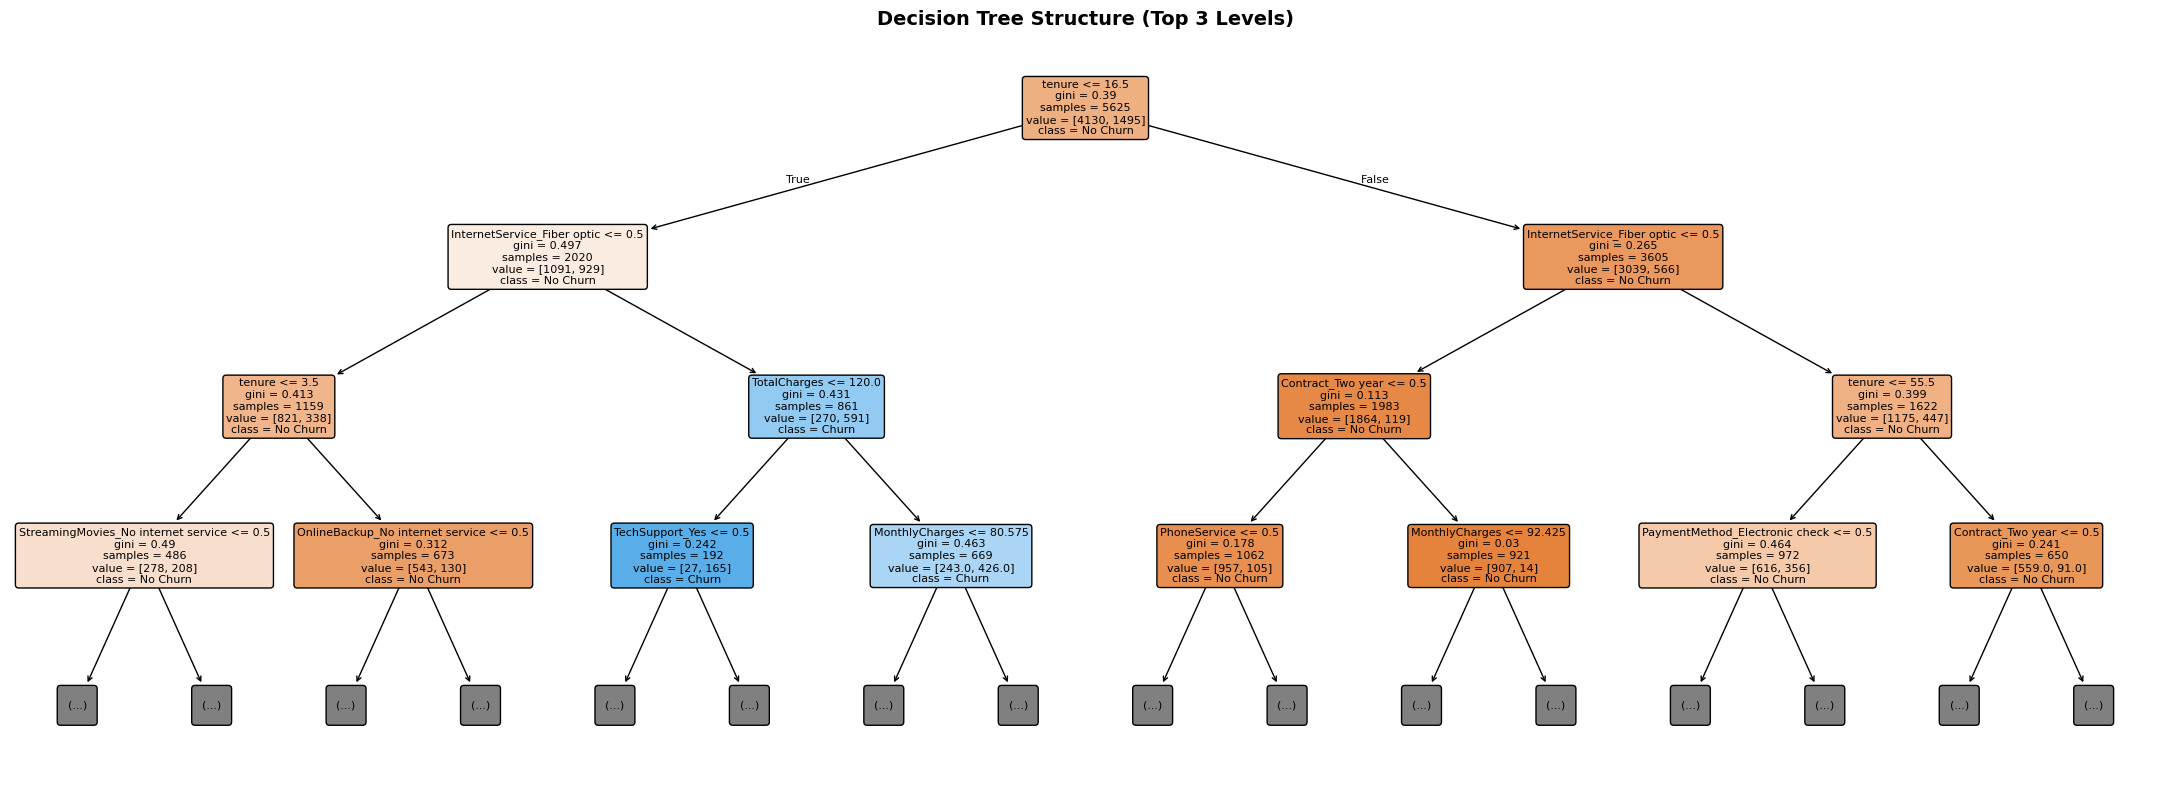

Saved: dt_tree_visualization.png


In [16]:
# 4. Visualize the Decision Tree (top 3 levels for readability)
plt.figure(figsize=(22, 8))
plot_tree(
    model_dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_visualization.png')

In [ ]:
# Try different max_depth values and see how accuracy changes
depths = range(1, 20)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, 'o-', color='mediumseagreen', label='Training Accuracy')
plt.plot(depths, test_accs, 's-', color='tomato', label='Test Accuracy')
plt.axvline(5, color='black', linestyle='--', alpha=0.5, label='Chosen depth = 5')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Accuracy vs Tree Depth', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('dt_depth_vs_accuracy.png', dpi=150)
plt.show()
print('Saved: dt_depth_vs_accuracy.png')